DATA LOAD


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Load the raw data
df_raw = pd.read_csv('ops_sensor_log_dirty.csv')

In [5]:
df_raw.head()

,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM
0,2026-07-01 18:28:00,Zone_South,Night,159.443407,83.599922,693.413088
1,2026-06-26 10:10:00,Zone_Central,NaN,271.325543,54.108382,933.590883
2,2026-06-29 22:10:00,Zone_Central,Morning,207.832279,72.549214,863.540549
3,2026-06-30 07:22:00,Zone_East,Night,203.110883,73.029484,1189.537650
4,2026-07-01 02:28:00,Zone_North,Morning,239.773496,73.752762,983.672559


In [2]:
def clean_ops_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans operational sensor logs by formatting dates, handling missing
    values, standardizing categories, and removing impossible outliers.
    """
    # Create a copy to avoid SettingWithCopyWarning
    df_clean = df.copy()

    # 1. Convert timestamps to datetime objects
    df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])

    # 2. Handle missing values
    # Justification: We drop rows with missing 'Shift' data. In operational
    # reporting, imputing a shift could misattribute critical safety/efficiency
    # metrics to the wrong team. It is safer to remove incomplete records.
    df_clean = df_clean.dropna(subset=['Shift'])

    # Fill any missing numerical sensor data with linear interpolation to maintain continuity
    numerical_cols = ['Pressure_PSI', 'Temperature_C', 'Flow_Rate_LPM']
    df_clean[numerical_cols] = df_clean[numerical_cols].interpolate(method='linear')

    # 3. Remove duplicate records
    df_clean = df_clean.drop_duplicates()

    # 4. Standardize categorical columns
    df_clean['Zone'] = df_clean['Zone'].str.strip().str.title()
    df_clean['Shift'] = df_clean['Shift'].str.strip().str.title()

    # 5. Filter out physically impossible sensor outliers
    # Assuming realistic bounds: Pressure (0-400 PSI), Temp (0-150 C)
    df_clean = df_clean[
        (df_clean['Pressure_PSI'] > 0) & (df_clean['Pressure_PSI'] <= 400) &
        (df_clean['Temperature_C'] > 0) & (df_clean['Temperature_C'] <= 150)
    ]

    return df_clean

# Execute the cleaning pipeline
df_cleaned = clean_ops_data(df_raw)

In [7]:
df_cleaned.head()

,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM
0,2026-07-01 18:28:00,Zone_South,Night,159.443407,83.599922,693.413088
2,2026-06-29 22:10:00,Zone_Central,Morning,207.832279,72.549214,863.540549
3,2026-06-30 07:22:00,Zone_East,Night,203.110883,73.029484,1189.537650
4,2026-07-01 02:28:00,Zone_North,Morning,239.773496,73.752762,983.672559
5,2026-06-29 18:04:00,Zone_Central,Morning,170.679549,54.308328,1062.156470


In [3]:
# Set timestamp as index and sort chronologically
df_ts = df_cleaned.set_index('timestamp').sort_index()

# Resample to hourly frequency and calculate the mean for each hour
hourly_data = df_ts.resample('H').mean(numeric_only=True)

# Calculate a 24-hour rolling average for Pressure_PSI
hourly_data['Pressure_24h_MA'] = hourly_data['Pressure_PSI'].rolling(window=24, min_periods=1).mean()

/tmp/ipykernel_9396/3331425821.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = df_ts.resample('H').mean(numeric_only=True)


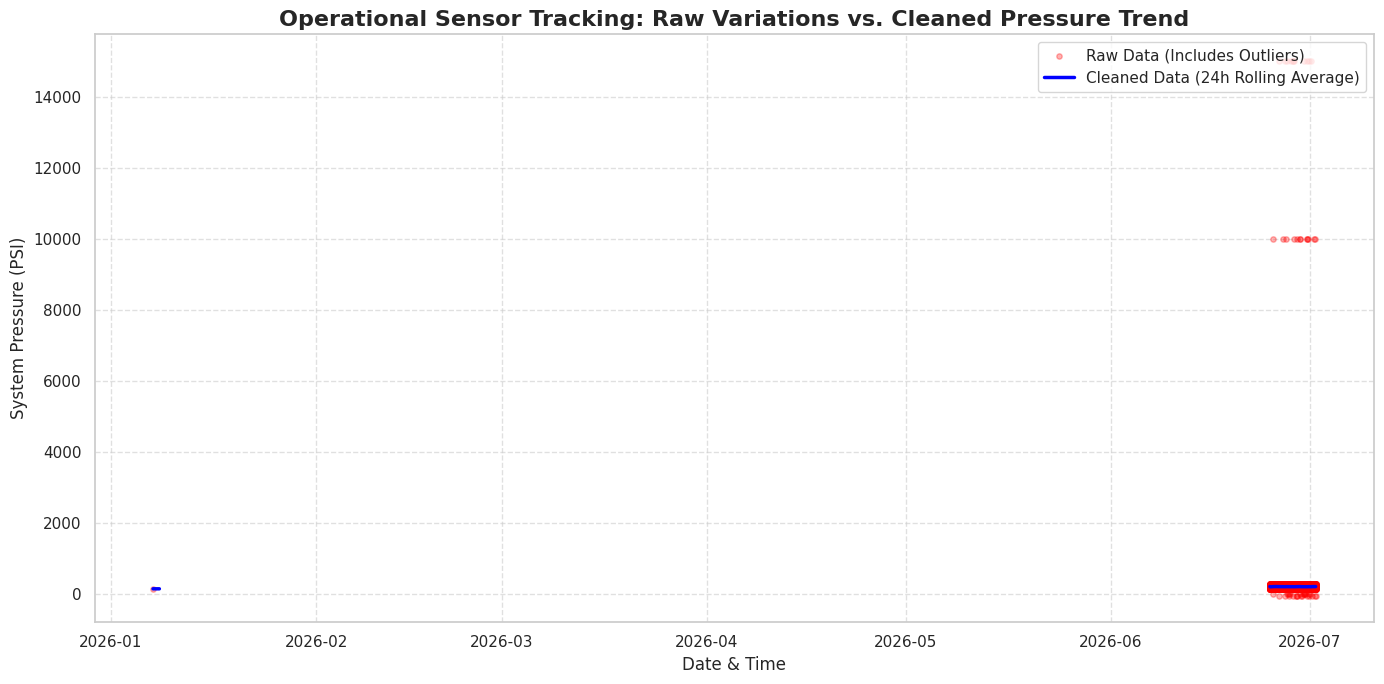

In [4]:
# Prepare raw data for comparison (converting timestamp just for plotting)
df_raw_plot = df_raw.copy()
df_raw_plot['timestamp'] = pd.to_datetime(df_raw_plot['timestamp'])
df_raw_plot = df_raw_plot.set_index('timestamp').sort_index()

# Plotting Raw vs Cleaned Data
plt.figure(figsize=(14, 7))

# Plot raw data as a scatter to show outliers
plt.scatter(
    df_raw_plot.index,
    df_raw_plot['Pressure_PSI'],
    color='red',
    alpha=0.3,
    label='Raw Data (Includes Outliers)',
    s=15
)

# Plot cleaned 24-hour rolling average as a solid line
plt.plot(
    hourly_data.index,
    hourly_data['Pressure_24h_MA'],
    color='blue',
    linewidth=2.5,
    label='Cleaned Data (24h Rolling Average)'
)

# Formatting the plot
plt.title('Operational Sensor Tracking: Raw Variations vs. Cleaned Pressure Trend', fontsize=16, fontweight='bold')
plt.xlabel('Date & Time', fontsize=12)
plt.ylabel('System Pressure (PSI)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Render the plot
plt.show()